# Code to dev SVMs for time averaged stimuli for review rebuttal

In [1]:
import argparse
import numpy as np
import h5py
from pathlib import Path
import pickle

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
TIME_AVG_EMB_PATH = \
    "/om2/user/imgriff/projects/torch_2_aud_attn/acts_for_RDM_analysis/word_task_v10_main_feature_gain_config/word_task_v10_main_feature_gain_config_model_activations_0dB_time_avg.h5"
FULL_TIME_EMB_PATH = \
    "/om2/user/imgriff/projects/torch_2_aud_attn/binaural_unit_activations/word_task_v10_main_feature_gain_config/word_task_v10_main_feature_gain_config_model_activations_0dB.h5"

LAYERS = [
    "norm_coch_rep",
    "conv_block_0_relu",
    "conv_block_1_relu",
    "conv_block_2_relu",
    "conv_block_3_relu",
    "conv_block_4_relu",
    "conv_block_5_relu",
    "conv_block_6_relu",
    "relufc",
]

SIGNALS = [
    "cue",
    "target",
    "same_sex_sig",
    "diff_sex_sig",
    "nat_scene_sig",
    "mixture_same_sex",
    "mixture_diff_sex",
    "mixture_nat_scene",
]

ATTN_TYPES = ["single_source", "cued"]

In [3]:
def _walk_keys(h5):
    keys = []
    def visitor(name, obj):
        if isinstance(obj, h5py.Dataset):
            keys.append(name)
    h5.visititems(visitor)
    return keys


def find_embeddings_dataset(h5, layer, signal, attn):
    candidates = _walk_keys(h5)
    # Prefer exact containment of all three identifiers in path
    ranked = [k for k in candidates if layer in k and signal in k and attn in k]
    if not ranked:
        # Try any two of the three
        two_match = [k for k in candidates if sum(s in k for s in (layer, signal, attn)) >= 2]
        ranked = two_match
    if not ranked and candidates:
        # Fallback: any dataset under layer
        ranked = [k for k in candidates if layer in k] or candidates
    for key in ranked:
        ds = h5[key]
        if isinstance(ds, h5py.Dataset) and np.issubdtype(ds.dtype, np.number):
            return key
    raise RuntimeError("Could not locate numeric embeddings dataset matching identifiers.")


def load_embeddings(h5, layer, signal, attn):
    key = find_embeddings_dataset(h5, layer, signal, attn)
    X = np.array(h5[key])
    # If time dimension present, average over it to produce fixed-size vectors
    if X.ndim > 2:
        # heuristics: average over axis with largest size if 3D and one axis equals feature dim
        time_axis = 1 if X.shape[1] >= X.shape[2] else 0
        X = X.mean(axis=time_axis)
    if X.ndim == 1:
        X = X[:, None]
    return X, key


def load_labels(h5, target, num_f0_bins=8):
    def get_any(keys):
        for k in keys:
            if k in h5:
                return np.array(h5[k])
        # search nested
        for path in _walk_keys(h5):
            if any(k in path for k in keys):
                return np.array(h5[path])
        return None

    if target == "location":
        loc = get_any(["target_loc"])
        if loc is None:
            raise RuntimeError("No location labels found for location.")
        loc = np.asarray(loc)
        # Map unique (azimuth, elevation) tuples or single-value locations to integer classes
        if loc.ndim >= 2 and loc.shape[-1] == 2:
            loc_2d = loc.reshape(-1, 2)
            _, y = np.unique(loc_2d, axis=0, return_inverse=True)
        else:
            _, y = np.unique(loc, return_inverse=True)
        return y.astype(int)

    if target == "f0_bin":
        f0 = get_any(["target_f0"])
        if f0 is None:
            raise RuntimeError("No f0 labels found for f0_bin.")
        f0 = np.asarray(f0).astype(float)
        # Bin into equal-count bins (quantile-based binning)
        quantiles = np.linspace(0, 1, num_f0_bins + 1)
        edges = np.quantile(f0, quantiles)
        # np.digitize returns 1..len(edges)-1; shift to 0-based
        y = np.digitize(f0, edges[1:-1], right=True).astype(int)
        return y

    if target == "word_class":
        word = get_any(["target_word_int"])
        if word is None:
            raise RuntimeError("No word class labels found.")
        word = np.array(word)
        # Ensure integer classes
        if not np.issubdtype(word.dtype, np.integer):
            # Try to map to categorical codes
            _, y = np.unique(word, return_inverse=True)
            return y.astype(int)
        return word.astype(int)

    raise ValueError(f"Unknown target: {target}")

In [4]:
def split_data(X, y, test_size=0.2, random_state=42):
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)


def cross_validate_svm(X_train, y_train, cv=5):
    param_grid = {"estimator__C": [0.1, 1, 10]}
    ovr = OneVsRestClassifier(LinearSVC(max_iter=2000, dual=True, random_state=0))
    grid_search = GridSearchCV(ovr, param_grid, cv=cv, n_jobs=-1, scoring="accuracy")
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    cv_scores = cross_val_score(best_model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    return best_model, grid_search.best_params_, float(np.mean(cv_scores)), float(1.0 - np.mean(cv_scores)), float(np.std(cv_scores))


def run_one_vs_rest_svm(X, y):
    X_train, X_test, y_train, y_test = split_data(X, y)
    best_model, best_params, mean_acc, mean_err, std_acc = cross_validate_svm(X_train, y_train)
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    acc = float(accuracy_score(y_test, y_pred))
    report = classification_report(y_test, y_pred)
    return {
        "model": best_model,
        "cv_mean_accuracy": mean_acc,
        "cv_std_accuracy": std_acc,
        "cv_mean_error": mean_err,
        "test_accuracy": acc,
        "classification_report": report,
        "best_params": best_params,
    }

In [5]:
layer = LAYERS[0]
signal = SIGNALS[1]
attn = ATTN_TYPES[0]

h5_path = TIME_AVG_EMB_PATH
with h5py.File(h5_path, "r") as h5:
    X, emb_key = load_embeddings(h5, layer, signal, attn)
    y = load_labels(h5, "word_class", num_f0_bins=14)

/tmp/ipykernel_3950311/2314985803.py:30: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  X = np.array(h5[key])
/tmp/ipykernel_3950311/2314985803.py:45: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  return np.array(h5[k])


In [6]:
# Align X and y lengths
n = min(len(X), len(y))
X, y = X[:n], y[:n]

# Drop NaNs/inf
mask = np.isfinite(X).all(axis=1) & np.isfinite(y)
X, y = X[mask], y[mask]

In [7]:
run_one_vs_rest_svm(X, y)

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/sklearn/svm/_base.py:1242: ConvergenceWarning: Liblinear failed

{'model': OneVsRestClassifier(estimator=LinearSVC(C=10, dual=True, max_iter=2000,
                                         random_state=0)),
 'cv_mean_accuracy': 0.9982142857142857,
 'cv_std_accuracy': 0.0035714285714285587,
 'cv_mean_error': 0.0017857142857142794,
 'test_accuracy': 1.0,
 'classification_report': '              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00         6\n           1       1.00      1.00      1.00         6\n           2       1.00      1.00      1.00         6\n           3       1.00      1.00      1.00         5\n           4       1.00      1.00      1.00         5\n           5       1.00      1.00      1.00         6\n           6       1.00      1.00      1.00         5\n           7       1.00      1.00      1.00         6\n           8       1.00      1.00      1.00         5\n           9       1.00      1.00      1.00         6\n          10       1.00      1.00      1.00         6\n          11       1.0

# Plotting

In [8]:
import os
import matplotlib.pyplot as plt

In [26]:
results_path = "/om2/user/rphess/Auditory-Attention/models/svm"

results = {}
for file in os.listdir(results_path):
    if file.endswith(".pkl"):
        with open(os.path.join(results_path, file), "rb") as f:
            out = pickle.load(f)
            key = out['target']
            if key not in results:
                results[key] = []
            results[key].append(out)

results.keys()

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.0.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.0.2 when using version 1.3.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/sklearn/base.py:347: InconsistentVersionWarning: Trying to 

dict_keys(['f0_bin', 'location', 'word_class'])

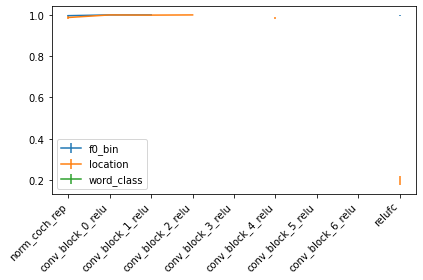

In [ ]:
# plot the model accuracy for each target with layer as the x-axis,
# in the order specified by the LAYERS list

for targets in results.keys():
    results_list = results[targets]
    # Build a mapping from layer name to (mean, std)
    layer_to_metrics = {}
    for result in results_list:
        layer = result['layer']
        mean = result['metrics']['cv_mean_accuracy']
        std = result['metrics']['cv_std_accuracy']
        layer_to_metrics[layer] = (mean, std)
    # For each layer in LAYERS, get the mean and std if present, else np.nan
    means = []
    stds = []
    for layer in LAYERS:
        if layer in layer_to_metrics:
            mean, std = layer_to_metrics[layer]
        else:
            mean, std = np.nan, np.nan
        means.append(mean)
        stds.append(std)
    plt.errorbar(LAYERS, means, yerr=stds, label=targets)

plt.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()